# Bangla Movie Review — Sentiment Analysis with BanglaBERT

**Dataset**: `bangla_movie_review_dataset.csv`  
**Task**: 3-class sentiment classification → Positive / Negative / Neutral  
**Model**: `csebuetnlp/banglabert` (BanglaBERT)  
**Language**: Pure Bangla only (Banglish rows removed)  
**Checkpointing**: Auto-resume from last checkpoint if training is interrupted  
**Hub Push**: Final best model pushed to HuggingFace Hub automatically

---

### Pipeline Overview
```
Raw CSV → Data Cleaning → Bangla-only Filter → Tokenization
       → Stop Word Removal → Label Encoding → Train/Val/Test Split
       → BanglaBERT Fine-tuning (with checkpoint resume)
       → Evaluation (Acc / F1 / Precision / Recall / CM)
       → Push best model to HuggingFace Hub
```

---
## Step 1 — Install & Import Dependencies

In [1]:
# Run once — comment out after first install
!pip install transformers datasets torch scikit-learn pandas numpy \
             matplotlib seaborn bnlp-toolkit huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 22.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.1 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from huggingface_hub import HfApi, login

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix,
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


---
## Step 2 — HuggingFace Hub Login

Login is required to:
- Push the trained model to your Hub repo at the end
- (Optional) Push intermediate checkpoints to Hub

**How to get your token**:  
Go to → https://huggingface.co/settings/tokens → New token → Role: `write`

In [4]:
from kaggle_secrets import UserSecretsClient

secret = UserSecretsClient()
hf_token = secret.get_secret("HF_TOKEN")


HF_USERNAME  = 'pritom-banik'          
HF_REPO_NAME = 'banglabert-movie-sentiment' 

HF_REPO_ID = f'{HF_USERNAME}/{HF_REPO_NAME}'  

login(token=hf_token)   


print(f'Will push final model to: https://huggingface.co/{HF_REPO_ID}')

Will push final model to: https://huggingface.co/pritom-banik/banglabert-movie-sentiment


---
## Step 3 — Load Dataset

In [7]:
df = pd.read_excel('/kaggle/input/datasets/pritombanik/movie-review-2000-pos-neg/movie_reviews_dataset_2000_bangla.xlsx')

# Keep only relevant columns
df = df[['review_text', 'sentiment']].copy()

print('Raw dataset shape:', df.shape)
print()
print('Sentiment distribution (raw):')
print(df['sentiment'].value_counts())
df.head()

Raw dataset shape: (2000, 2)

Sentiment distribution (raw):
sentiment
Positive    687
Neutral     669
Negative    644
Name: count, dtype: int64


,review_text,sentiment
0,একবার দেখা যায়,Neutral
1,একেবারেই পছন্দ হয়নি,Negative
2,অভিনয় খারাপ। একেবারেই পছন্দ হয়নি,Negative
3,একদমই ভালো লাগেনি। ভালো কিছু আশা করেছিলাম কিন্...,Negative
4,ওভারহাইপড মনে হয়েছে। বিরক্তিকর লেগেছে। ভালো ক...,Negative


---
## Step 4 — Data Cleaning

1. Drop null rows  
2. Normalise sentiment labels (case-insensitive merge)  
3. Remove duplicates  
4. Strip whitespace  
5. Remove empty strings

In [9]:
df.dropna(subset=['review_text', 'sentiment'], inplace=True)
print('After dropping nulls:', len(df))

df['sentiment'] = df['sentiment'].str.strip().str.capitalize()

VALID_LABELS = {'Positive', 'Negative', 'Neutral'}
df = df[df['sentiment'].isin(VALID_LABELS)].copy()
print('After label filter:', len(df))

df.drop_duplicates(subset=['review_text'], inplace=True)
print('After deduplication:', len(df))

df['review_text'] = df['review_text'].str.strip()
df = df[df['review_text'].str.len() > 0].copy()
df.reset_index(drop=True, inplace=True)

print('\nFinal class distribution:')
print(df['sentiment'].value_counts())

After dropping nulls: 473
After label filter: 473
After deduplication: 473

Final class distribution:
sentiment
Positive    227
Negative    221
Neutral      25
Name: count, dtype: int64


---
## Step 5 — Filter: Keep Only Pure Bangla (Remove Banglish)

In [10]:
def is_pure_bangla(text: str, max_english_ratio: float = 0.3) -> bool:
    text = str(text)
    total_chars = len(text.replace(' ', ''))
    if total_chars == 0:
        return False
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    return (english_chars / total_chars) < max_english_ratio


df['is_bangla'] = df['review_text'].apply(is_pure_bangla)
print('Bangla rows  :', df['is_bangla'].sum())
print('Banglish rows:', (~df['is_bangla']).sum())

df = df[df['is_bangla']].drop(columns=['is_bangla']).copy()
df.reset_index(drop=True, inplace=True)

print('\nDataset after Bangla filter:', len(df))
print(df['sentiment'].value_counts())

Bangla rows  : 473
Banglish rows: 0

Dataset after Bangla filter: 473
sentiment
Positive    227
Negative    221
Neutral      25
Name: count, dtype: int64


---
## Step 6 — Text Cleaning (Bangla-Specific)

In [11]:
def clean_bangla_text(text: str) -> str:
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'<.*?>', '', text)                # HTML tags
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text) # keep Bangla Unicode only
    text = re.sub(r'\s+', ' ', text)                 # collapse spaces
    return text.strip()


df['cleaned_text'] = df['review_text'].apply(clean_bangla_text)
df = df[df['cleaned_text'].str.len() > 2].copy()
df.reset_index(drop=True, inplace=True)

print('After text cleaning:', len(df))
print()
for i in range(3):
    print(f'  Original : {df["review_text"][i][:80]}')
    print(f'  Cleaned  : {df["cleaned_text"][i][:80]}')
    print()

After text cleaning: 473

  Original : একবার দেখা যায়
  Cleaned  : একবার দেখা যায়

  Original : একেবারেই পছন্দ হয়নি
  Cleaned  : একেবারেই পছন্দ হয়নি

  Original : অভিনয় খারাপ। একেবারেই পছন্দ হয়নি
  Cleaned  : অভিনয় খারাপ একেবারেই পছন্দ হয়নি



---
## Step 7 — Bangla Stop Word Removal

In [12]:
try:
    from bnlp import BengaliStopWords
    STOP_WORDS = set(BengaliStopWords().load_stopwords())
    print(f'Loaded {len(STOP_WORDS)} stop words from bnlp-toolkit')
except Exception as e:
    print(f'bnlp unavailable ({e}), using manual list')
    STOP_WORDS = set([
        'এই','ও','এবং','তার','আর','কিন্তু','যে','থেকে','এতে',
        'না','হয়','তো','আমি','আমার','তারা','সে','এখানে','এখন',
        'তখন','হলো','এটি','সব','একটি','একটা','ছিল','এটা','আছে',
        'করে','যা','হয়েছে','আমাদের','মতো','কি','কোনো','দেখে',
        'দিয়ে','সাথে','জন্য','হবে','যদি','তাই','তবে','আবার',
    ])


def remove_stopwords(text: str) -> str:
    return ' '.join(t for t in text.split() if t not in STOP_WORDS)


# Stop words removed for EDA; BERT input keeps them (attention handles them)
df['text_no_stopwords'] = df['cleaned_text'].apply(remove_stopwords)
df['bert_input']        = df['cleaned_text']  # full cleaned text for BERT

print('Sample after stop word removal:')
print(df['text_no_stopwords'].head(3).tolist())

bnlp unavailable (cannot import name 'BengaliStopWords' from 'bnlp' (/usr/local/lib/python3.12/dist-packages/bnlp/__init__.py)), using manual list
Sample after stop word removal:
['একবার দেখা যায়', 'একেবারেই পছন্দ হয়নি', 'অভিনয় খারাপ একেবারেই পছন্দ হয়নি']


---
## Step 8 — Tokenization Preview

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Sample text  : একবার দেখা যায়
Tokens       : ['একবার', 'দেখা', 'যায়']
Token count  : 3

Token length stats:
count    473.000000
mean       9.067653
std        2.920499
min        2.000000
25%        7.000000
50%        9.000000
75%       11.000000
max       16.000000
Name: bert_input, dtype: float64


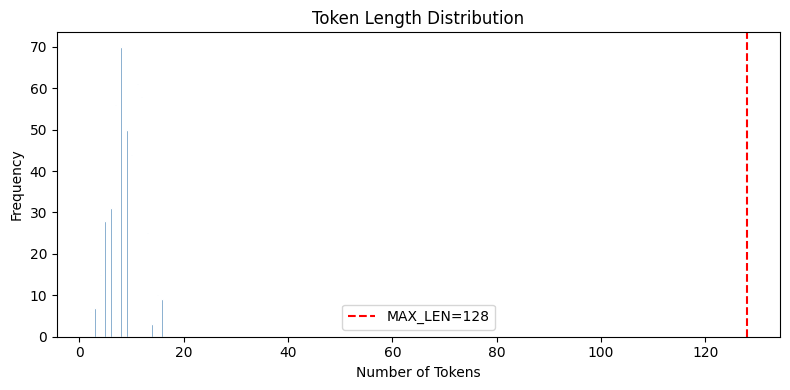

Rows > 128 tokens: 0 (0.0%)


In [13]:
MODEL_NAME = 'csebuetnlp/banglabert'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

sample = df['bert_input'].iloc[0]
tokens = tokenizer.tokenize(sample)
print('Sample text  :', sample)
print('Tokens       :', tokens)
print('Token count  :', len(tokens))

all_lengths = df['bert_input'].apply(lambda t: len(tokenizer.tokenize(t)))
print('\nToken length stats:')
print(all_lengths.describe())

plt.figure(figsize=(8, 4))
plt.hist(all_lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(128, color='red', linestyle='--', label='MAX_LEN=128')
plt.title('Token Length Distribution')
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Rows > 128 tokens: {(all_lengths > 128).sum()} ({(all_lengths > 128).mean()*100:.1f}%)')

---
## Step 9 — Label Encoding & Train / Val / Test Split

In [15]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

print('Label mapping:')
for idx, cls in enumerate(le.classes_):
    print(f'  {idx} → {cls}')

NUM_LABELS  = len(le.classes_)
LABEL_NAMES = list(le.classes_)

X = df['bert_input'].tolist()
y = df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f'\nTrain: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Label mapping:
  0 → Negative
  1 → Neutral
  2 → Positive

Train: 378  |  Val: 47  |  Test: 48


---
## Step 10 — PyTorch Dataset Class

In [16]:
MAX_LEN = 128


class BanglaReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = BanglaReviewDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = BanglaReviewDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = BanglaReviewDataset(X_test,  y_test,  tokenizer, MAX_LEN)

print(f'Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}')

Train: 378  Val: 47  Test: 48


---
## Step 11 — Load BanglaBERT

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

Total params    : 110,619,651
Trainable params: 110,619,651


---
## Step 12 — Checkpoint Detection (Resume from Last Checkpoint)

Before training starts, we check whether a previous interrupted run left a checkpoint.  
If yes, `trainer.train()` will **automatically resume from that exact step** — no epochs are repeated.

| Situation | What happens |
|---|---|
| First run / no checkpoint found | Trains from epoch 1, step 1 |
| Interrupted at epoch 2, step 150 | Resumes from epoch 2, step 150 |
| Training already complete | Skips training, loads best checkpoint |

In [18]:
CHECKPOINT_DIR = '/kaggle/working/banglabert_checkpoints'
SAVE_PATH      = '/kaggle/working/banglabert_sentiment_final'


def get_last_checkpoint(checkpoint_dir: str):
    if not os.path.isdir(checkpoint_dir):
        return None

    checkpoints = [
        d for d in os.listdir(checkpoint_dir)
        if d.startswith('checkpoint-') and
           os.path.isdir(os.path.join(checkpoint_dir, d))
    ]
    if not checkpoints:
        return None

    # Sort by step number and return the highest
    checkpoints.sort(key=lambda x: int(x.split('-')[-1]))
    last = os.path.join(checkpoint_dir, checkpoints[-1])
    return last


last_checkpoint = get_last_checkpoint(CHECKPOINT_DIR)

if last_checkpoint:
    print(f'Checkpoint found, will resume from: {last_checkpoint}')
else:
    print('No checkpoint found, will train from scratch')

No checkpoint found, will train from scratch


---
## Step 13 — Training Configuration

Key checkpoint & Hub settings explained:

| Argument | Value | Purpose |
|---|---|---|
| `output_dir` | `CHECKPOINT_DIR` | Where all checkpoints are saved locally |
| `save_strategy` | `'epoch'` | Save a checkpoint after every epoch |
| `save_total_limit` | `2` | Keep only the 2 most recent checkpoints (saves disk) |
| `load_best_model_at_end` | `True` | After training, reload the best checkpoint automatically |
| `push_to_hub` | `True` | Enable automatic push to HuggingFace Hub |
| `hub_model_id` | `HF_REPO_ID` | Your Hub repo (`username/repo-name`) |
| `hub_strategy` | `'every_save'` | Push to Hub every time a checkpoint is saved |
| `hub_private_repo` | `True` | Repo is private until you decide to make it public |

In [19]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy'    : accuracy_score(labels, preds),
        'f1_macro'    : f1_score(labels, preds, average='macro'),
        'f1_weighted' : f1_score(labels, preds, average='weighted'),
        'precision'   : precision_score(labels, preds, average='macro', zero_division=0),
        'recall'      : recall_score(labels, preds, average='macro'),
    }


training_args = TrainingArguments(
    # Local output & checkpointing 
    output_dir             = CHECKPOINT_DIR,
    save_strategy          = 'epoch',      # checkpoint after every epoch
    save_total_limit       = 2,            # keep only 2 latest checkpoints locally
    load_best_model_at_end = True,         # restore best checkpoint when done
    metric_for_best_model  = 'f1_macro',
    greater_is_better      = True,

    # HuggingFace Hub push
    push_to_hub            = True,
    hub_model_id           = HF_REPO_ID,   # 'username/repo-name'
    hub_strategy           = 'every_save', # push every checkpoint to Hub
    hub_private_repo       = True,         # private repo (change to False to make public)

    # Hyperparameters
    num_train_epochs            = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    lr_scheduler_type           = 'linear',

    # Evaluation & logging
    eval_strategy  = 'epoch',
    logging_dir    = './logs',
    logging_steps  = 50,

    fp16 = torch.cuda.is_available(),  # mixed precision on GPU
    seed = SEED,
)

print('Training arguments ready.')
print(f'Checkpoints saved to : {CHECKPOINT_DIR}')
print(f'Hub repo             : https://huggingface.co/{HF_REPO_ID}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training arguments ready.
Checkpoints saved to : /kaggle/working/banglabert_checkpoints
Hub repo             : https://huggingface.co/pritom-banik/banglabert-movie-sentiment


---
## Step 14 — Train (with Auto-Resume)

Passing `resume_from_checkpoint=last_checkpoint` to `trainer.train()` is the key:

- If `last_checkpoint` is `None` → starts fresh
- If `last_checkpoint` is a path → **resumes from that exact step**, including:
  - Model weights
  - Optimizer state
  - LR scheduler state
  - RNG states (for reproducibility)
  - DataLoader position

Every epoch end: checkpoint saved locally **and** pushed to your Hub repo automatically.

In [22]:
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

# resume_from_checkpoint:
trainer.train(resume_from_checkpoint=last_checkpoint)

print('\n Training complete.')
print(f'Best checkpoint: {trainer.state.best_model_checkpoint}')
print(f'Best F1 macro  : {trainer.state.best_metric:.4f}')

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
1,No log,1.587979,0.957447,0.652174,0.937095,0.638889,0.666667
2,No log,1.066527,0.957447,0.652174,0.937095,0.638889,0.666667
3,No log,0.749234,0.957447,0.652174,0.937095,0.638889,0.666667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye


 Training complete.
Best checkpoint: /kaggle/working/banglabert_checkpoints/checkpoint-12
Best F1 macro  : 0.6522


---
## Step 15 — Evaluate on Test Set

In [23]:
test_results = trainer.evaluate(test_dataset)
print('=== Test Set Results ===')
for k, v in test_results.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')

=== Test Set Results ===
  eval_loss: 1.6300
  eval_accuracy: 0.9375
  eval_f1_macro: 0.6454
  eval_f1_weighted: 0.9082
  eval_precision: 0.6267
  eval_recall: 0.6667
  eval_runtime: 0.2946
  eval_samples_per_second: 162.9370
  eval_steps_per_second: 3.3950
  epoch: 3.0000


---
## Step 16 — Detailed Classification Report

In [24]:
pred_output = trainer.predict(test_dataset)
y_pred = np.argmax(pred_output.predictions, axis=-1)
y_true = pred_output.label_ids

print('Classification Report')
print(classification_report(y_true, y_pred, target_names=LABEL_NAMES))

Classification Report
              precision    recall  f1-score   support

    Negative       0.88      1.00      0.94        22
     Neutral       0.00      0.00      0.00         3
    Positive       1.00      1.00      1.00        23

    accuracy                           0.94        48
   macro avg       0.63      0.67      0.65        48
weighted avg       0.88      0.94      0.91        48



---
## Step 17 — Confusion Matrix

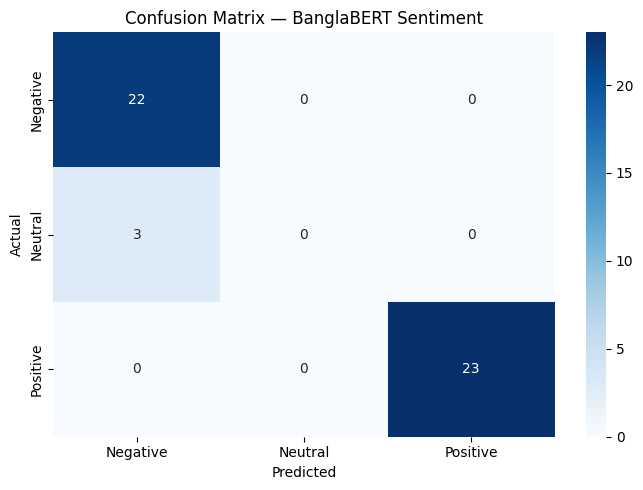

In [25]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('Confusion Matrix — BanglaBERT Sentiment')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

---
## Step 18 — Training Loss & Validation F1 Curves

ValueError: not enough values to unpack (expected 2, got 0)

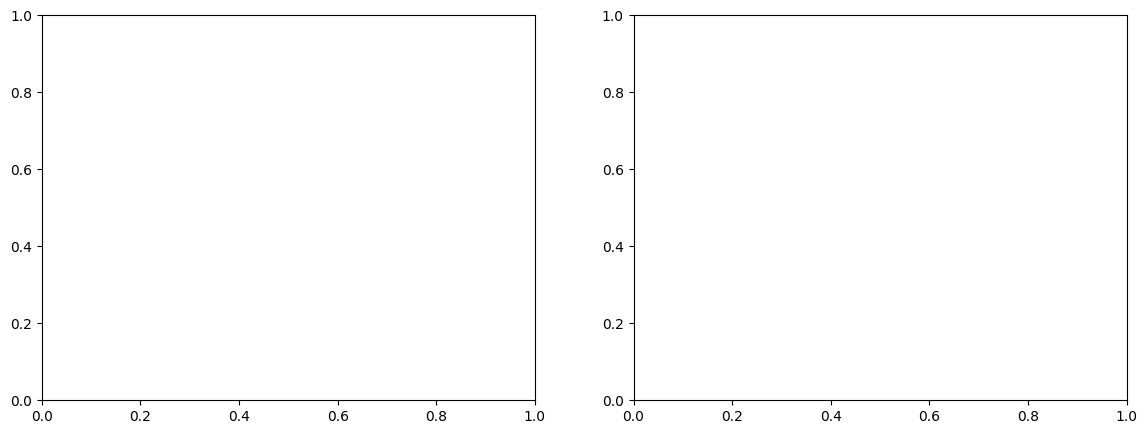

In [26]:
log_history  = trainer.state.log_history
train_losses = [(l['step'], l['loss'])           for l in log_history if 'loss' in l]
eval_f1s     = [(l['epoch'], l['eval_f1_macro']) for l in log_history if 'eval_f1_macro' in l]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

steps, t_loss = zip(*train_losses)
ax1.plot(steps, t_loss, color='steelblue', label='Train Loss')
ax1.set_title('Training Loss')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

if eval_f1s:
    epochs, f1s = zip(*eval_f1s)
    ax2.plot(epochs, f1s, marker='o', color='green', label='Val F1 Macro')
    ax2.set_title('Validation F1 (Macro)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

---
## Step 19 — Push Final Best Model to HuggingFace Hub

This is the **definitive push** of the best model (selected by `load_best_model_at_end=True`).  
It also uploads:
- `label_map.json` — maps `0/1/2` back to `Negative/Neutral/Positive`
- `README.md` (model card) — auto-generated by `push_to_hub`

After this cell runs you will find your model at:  
`https://huggingface.co/<your-username>/banglabert-movie-sentiment`

In [27]:
# Push model to tokenizer
print('Pushing best model to Hub...')
trainer.push_to_hub(
    commit_message='Final best model — BanglaBERT movie sentiment',
    blocking=True,   # wait until upload finishes before continuing
)
print('Model pushed.')

# Also push tokenizer explicitly
tokenizer.push_to_hub(HF_REPO_ID, commit_message='Add tokenizer')
print('Tokenizer pushed.')

#  Upload label_map.json as an extra file
label_map = {str(i): cls for i, cls in enumerate(LABEL_NAMES)}
label_map_path = 'label_map.json'
with open(label_map_path, 'w', encoding='utf-8') as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

api = HfApi()
api.upload_file(
    path_or_fileobj = label_map_path,
    path_in_repo    = 'label_map.json',
    repo_id         = HF_REPO_ID,
    repo_type       = 'model',
    commit_message  = 'Add label map (0=Negative, 1=Neutral, 2=Positive)',
)
print('label_map.json pushed.')
print(f'\n🔗 Model URL: https://huggingface.co/{HF_REPO_ID}')

Pushing best model to Hub...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Model pushed.


README.md: 0.00B [00:00, ?B/s]

Tokenizer pushed.
label_map.json pushed.

🔗 Model URL: https://huggingface.co/pritom-banik/banglabert-movie-sentiment


---
## Step 20 — Load Model Directly from Hub & Run Inference

Anyone (with access to the repo) can now load and use the model in **one line** — no local files needed.

In [28]:
from transformers import pipeline

# Load directly from Hub
hub_classifier = pipeline(
    'text-classification',
    model     = HF_REPO_ID,
    tokenizer = HF_REPO_ID,
    device    = 0 if torch.cuda.is_available() else -1,
)

with open('label_map.json', 'r', encoding='utf-8') as f:
    hub_label_map = json.load(f)


def predict_from_hub(text: str) -> dict:
    cleaned  = clean_bangla_text(text)
    result   = hub_classifier(cleaned, truncation=True, max_length=MAX_LEN)[0]
    label_id = result['label'].replace('LABEL_', '')
    return {
        'text'      : text,
        'sentiment' : hub_label_map[label_id],
        'confidence': round(result['score'], 4),
    }


test_reviews = [
    'এই সিনেমাটি অসাধারণ ছিল, খুব ভালো লেগেছে।',
    'ভালো লাগে নাই, অনেক বোরিং।',
    'সিনেমাটি মোটামুটি ছিল।',
]

print('=== Inference from Hub ===')
for review in test_reviews:
    r = predict_from_hub(review)
    print(f"Text      : {r['text']}")
    print(f"Sentiment : {r['sentiment']}  (confidence: {r['confidence']})")
    print()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== Inference from Hub ===
Text      : এই সিনেমাটি অসাধারণ ছিল, খুব ভালো লেগেছে।
Sentiment : Positive  (confidence: 0.4428)

Text      : ভালো লাগে নাই, অনেক বোরিং।
Sentiment : Negative  (confidence: 0.4467)

Text      : সিনেমাটি মোটামুটি ছিল।
Sentiment : Positive  (confidence: 0.4328)



---
## Summary

| Step | Action |
|------|--------|
| 1 | Install dependencies (including `huggingface_hub`) |
| 2 | **HuggingFace Hub login** — `login()` |
| 3 | Load CSV dataset |
| 4 | Data cleaning |
| 5 | Bangla-only filter |
| 6 | Bangla text cleaning |
| 7 | Stop word removal |
| 8 | Tokenization preview |
| 9 | Label encoding + 80/10/10 split |
| 10 | PyTorch Dataset class |
| 11 | Load BanglaBERT |
| 12 | **Checkpoint detection** — `get_last_checkpoint()` |
| 13 | TrainingArguments with `push_to_hub=True`, `hub_strategy='every_save'` |
| 14 | **`trainer.train(resume_from_checkpoint=last_checkpoint)`** |
| 15 | Test set evaluation |
| 16 | Classification report |
| 17 | Confusion matrix |
| 18 | Training curves |
| 19 | **`trainer.push_to_hub()` — push best model + tokenizer + label_map** |
| 20 | **Load model from Hub + inference** |

### Resume Logic
```
Run notebook ──► get_last_checkpoint() scans CHECKPOINT_DIR
      │
      ├── No checkpoint found ──► train from epoch 1
      │
      └── checkpoint-N found ──► resume_from_checkpoint=checkpoint-N
                                  (weights + optimizer + scheduler + RNG restored)
```

### Hub Push Timeline
```
Epoch 1 ends → save checkpoint-N locally → push to Hub (hub_strategy='every_save')
Epoch 2 ends → save checkpoint-N+1      → push to Hub
...
Training complete → load_best_model_at_end loads best checkpoint
Step 19 → trainer.push_to_hub() pushes FINAL best model
```